**Importing the necessary libraries**


In [ ]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

**Preparing the dataset**

In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/Socket_Type_v11.zip"

Archive:  /content/drive/MyDrive/Socket_Type_v11.zip
   creating: Socket_Type_v11/
   creating: Socket_Type_v11/A_type/
  inflating: Socket_Type_v11/A_type/A-2_jpg.rf.8b73865b4c66bed5a9e7340c2107277a.jpg  
  inflating: Socket_Type_v11/A_type/A-4_png.rf.37278628e2105470e87a063599aee786.jpg  
  inflating: Socket_Type_v11/A_type/A-5_jpg.rf.c924d73e4f4b8a72c60d9225fb57f4d7.jpg  
  inflating: Socket_Type_v11/A_type/A-6_jpg.rf.e720fb9095b7ad79d86be8800c639ce1.jpg  
  inflating: Socket_Type_v11/A_type/A-8_png.rf.0826a73be51a6c85295de4c140995eb1.jpg  
  inflating: Socket_Type_v11/A_type/Type-A-1-_png.rf.450c91e3fdf4c03210b6ad5c5c9b0eb4.jpg  
  inflating: Socket_Type_v11/A_type/Type-A-2-_png.rf.77a5d3c72a6ff62243c1a69623e900a1.jpg  
  inflating: Socket_Type_v11/A_type/Type-A-3-_png.rf.473a2d6d4523e1f8ac0f499d8ca012bc.jpg  
  inflating: Socket_Type_v11/A_type/Type-A-4-_png.rf.f6b807024167d6556a5410e9195753c3.jpg  
  inflating: Socket_Type_v11/A_type/Type-A-6-_png.rf.82f9c3143307e5c34073497229d18

**Split the dataset into train valid and test**

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders
input_folder="/content/Socket_Type_v11/"
splitfolders.ratio(input_folder, output="output2", seed=1337, ratio=(0.7, 0.15, 0.15))

Copying files: 3191 files [00:00, 6733.46 files/s]


In [ ]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = '/content/output2/train/'
valid_path = '/content/output2/val/'
test_path='/content/output2/test/'

In [ ]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   horizontal_flip = True)
valid_datagen=ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
# Make sure you provide the same target size as initialied for the image size
train_set = train_datagen.flow_from_directory('/content/output2/train/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 2224 images belonging to 12 classes.


In [ ]:
val_set = valid_datagen.flow_from_directory('/content/output2/val/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 473 images belonging to 12 classes.


In [ ]:
test_set = valid_datagen.flow_from_directory('/content/output2/test/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 490 images belonging to 12 classes.


In [ ]:
num_classes = len(train_set.class_indices)

Found 490 images belonging to 12 classes.
Detected classes (12): ['A_type', 'B_Type', 'C_Type', 'DM_Type', 'E_Type', 'F_Type', 'G_Type', 'H_Type', 'I_Type', 'JN_Type', 'K_Type', 'L_Type']

Training VGG16 ...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step - accuracy: 0.1884 - loss: 2.4126 - val_accuracy: 0.4313 - val_loss: 1.9953
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.4788 - loss: 1.9128 - val_accuracy: 0.5856 - val_loss: 1.7027
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.5837 - loss: 1.6671 - val_accuracy: 0.5687 - val_loss: 1.5481
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.5925 - loss: 1.5472 - val_accuracy: 0.6638 - val_loss: 1.4111
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.6562 - loss: 1.3796 - val_accuracy: 0.6850 - val_loss: 1.3178
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.6641 - loss: 1.3319 - val_accuracy: 0.6808 - val_loss: 1.2509
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.6857 - loss: 1.2532 - val_accuracy: 0.6934 - val_loss: 1.1965
Epoch 8/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.7296 - loss: 1.1588 - val

VGG16 model saved as 'VGG16_weights.h5'

Training InceptionV3 ...
Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 160ms/step - accuracy: 0.4697 - loss: 1.7217 - val_accuracy: 0.8013 - val_loss: 0.7292
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7975 - loss: 0.6476 - val_accuracy: 0.8266 - val_loss: 0.5744
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.8833 - loss: 0.4189 - val_accuracy: 0.8795 - val_loss: 0.4657
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9070 - loss: 0.3278 - val_accuracy: 0.8837 - val_loss: 0.4303
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9324 - loss: 0.2650 - val_accuracy: 0.8795 - val_loss: 0.4092
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9554 - loss: 0.1947 - val_accuracy: 0.8753 - val_loss: 0.3978
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9599 - loss: 0.1757 - val_accuracy: 0.8943 - val_loss: 0.3722
Epoch 8/30
139/139 ━━━━━

InceptionV3 model saved as 'InceptionV3_weights.h5'

Training Xception ...
Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 227ms/step - accuracy: 0.4638 - loss: 1.7109 - val_accuracy: 0.7992 - val_loss: 0.8028
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.8120 - loss: 0.7040 - val_accuracy: 0.8393 - val_loss: 0.6289
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.8764 - loss: 0.5216 - val_accuracy: 0.8732 - val_loss: 0.5272
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.8861 - loss: 0.4103 - val_accuracy: 0.8710 - val_loss: 0.4778
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9227 - loss: 0.3328 - val_accuracy: 0.8816 - val_loss: 0.4433
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9327 - loss: 0.2911 - val_accuracy: 0.8943 - val_loss: 0.4132
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.9437 - loss: 0.2514 - val_accuracy: 0.9049 - val_loss: 0.3982
Epoch 8/30
139

Xception model saved as 'Xception_weights.h5'

Training ResNet50 ...
Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - accuracy: 0.1128 - loss: 2.4880 - val_accuracy: 0.1755 - val_loss: 2.3558
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.2237 - loss: 2.3253 - val_accuracy: 0.2347 - val_loss: 2.2447
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.2279 - loss: 2.2613 - val_accuracy: 0.2854 - val_loss: 2.1879
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.2680 - loss: 2.1939 - val_accuracy: 0.3129 - val_loss: 2.1449
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.3135 - loss: 2.1385 - val_accuracy: 0.3087 - val_loss: 2.1153
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.3244 - loss: 2.0803 - val_accuracy: 0.2727 - val_loss: 2.0604
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.3098 - loss: 2.0563 - val_accuracy: 0.3996 - val_loss: 2.0095
Epoch 8/30
139/139 ━

ResNet50 model saved as 'ResNet50_weights.h5'

Training ResNet101 ...
Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 182ms/step - accuracy: 0.1072 - loss: 2.5289 - val_accuracy: 0.1712 - val_loss: 2.3579
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.1638 - loss: 2.3562 - val_accuracy: 0.1691 - val_loss: 2.2804
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.2388 - loss: 2.2676 - val_accuracy: 0.2981 - val_loss: 2.2190
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.2597 - loss: 2.2196 - val_accuracy: 0.2960 - val_loss: 2.1672
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.2707 - loss: 2.1628 - val_accuracy: 0.2622 - val_loss: 2.1133
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.3096 - loss: 2.1184 - val_accuracy: 0.3192 - val_loss: 2.0868
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.3272 - loss: 2.0816 - val_accuracy: 0.3298 - val_loss: 2.0816
Epoch 8/30
13

ResNet101 model saved as 'ResNet101_weights.h5'

Performance Summary:
         Model  Accuracy  Precision    Recall  F1-score
0        VGG16  0.826531   0.846426  0.815650  0.819405
1  InceptionV3  0.897959   0.906668  0.900469  0.901018
2     Xception  0.912245   0.914095  0.909825  0.911418
3     ResNet50  0.491837   0.599042  0.476901  0.466101
4    ResNet101  0.442857   0.633603  0.428696  0.432741


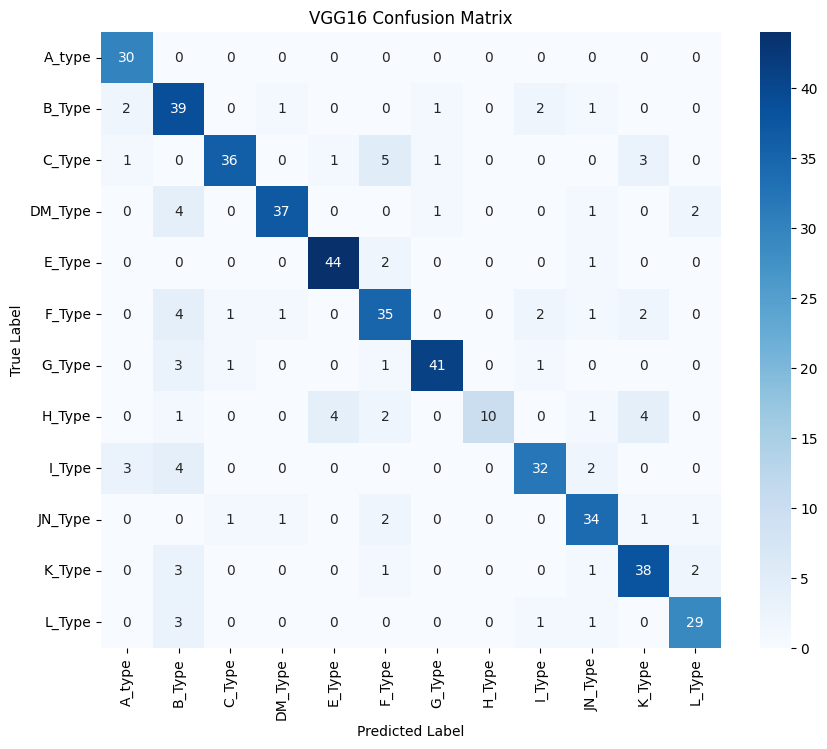

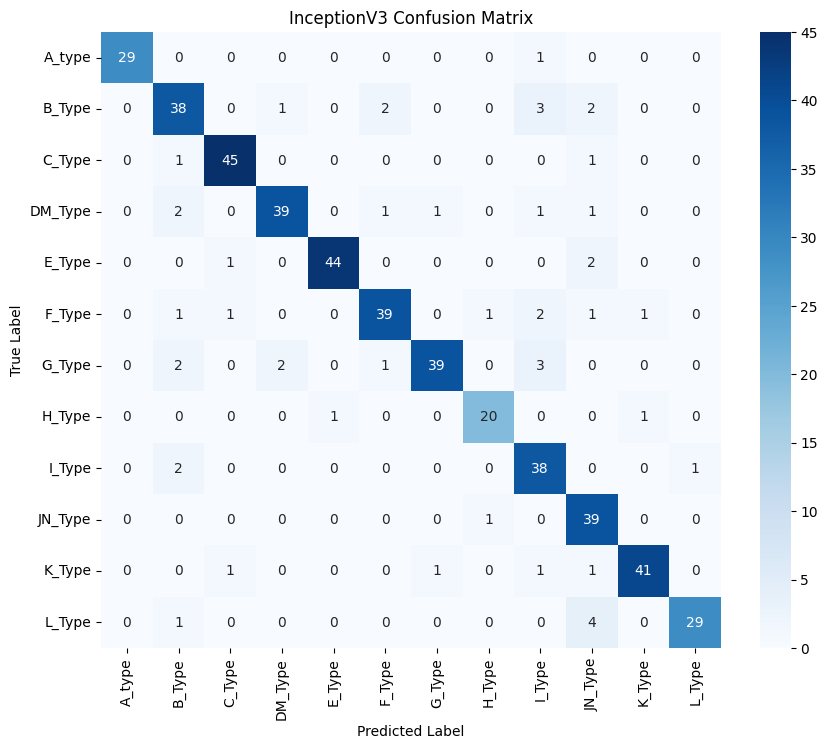

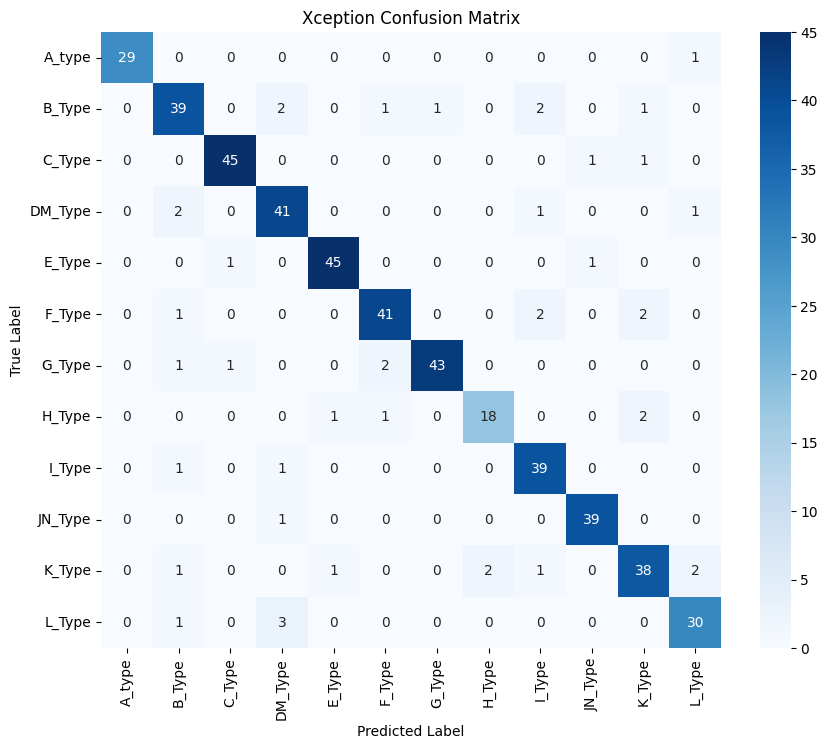

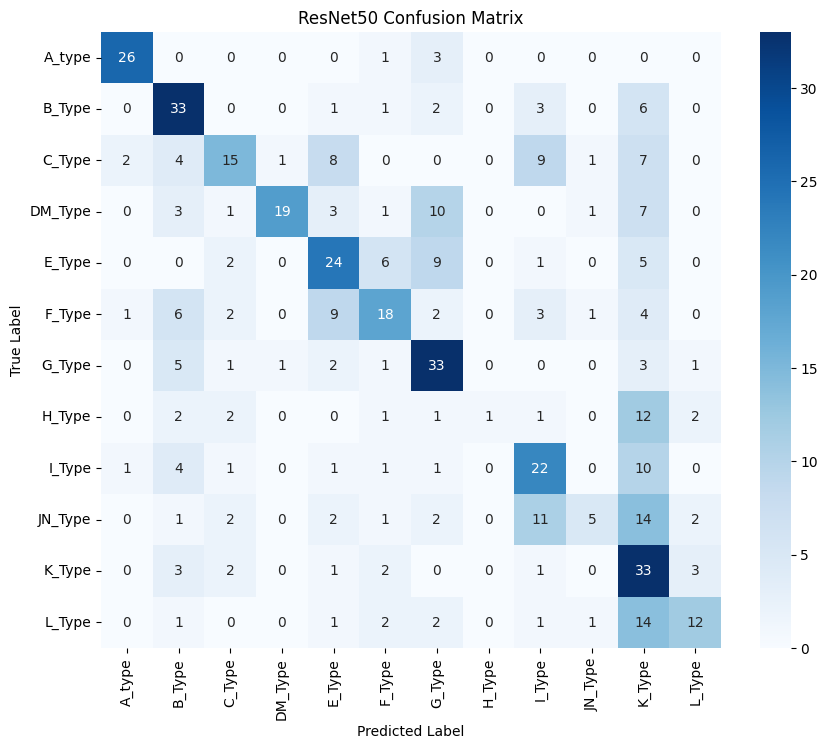

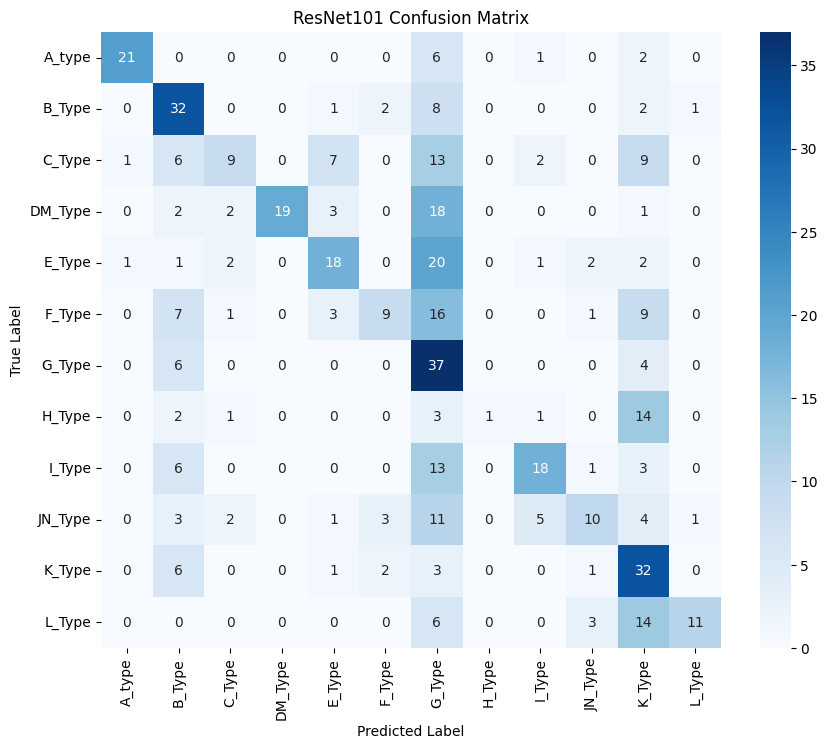

In [ ]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, InceptionV3, Xception, ResNet50, ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# ==============================
# SETTINGS
# ==============================
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 16
NUM_CLASSES = 12  # replace with your actual number of classes
EPOCHS = 30

# ==============================
# LOAD TEST/VALIDATION DATA
# ==============================
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
    '/content/output2/test',  # path to test/validation folder
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Automatically detect class names
classes = list(test_set.class_indices.keys())
print(f"Detected classes ({len(classes)}): {classes}")

# ==============================
# MODEL CREATION FUNCTION
# ==============================
def create_model(base_model_name, input_shape=IMAGE_SIZE + [3], num_classes=NUM_CLASSES):
    if base_model_name == "VGG16":
        base_model = VGG16(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "InceptionV3":
        base_model = InceptionV3(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "Xception":
        base_model = Xception(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "ResNet50":
        base_model = ResNet50(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "ResNet101":
        base_model = ResNet101(input_shape=input_shape, weights='imagenet', include_top=False)
    else:
        raise ValueError("Unknown model name")

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ==============================
# INITIALIZE MODELS
# ==============================
model_names = ["VGG16", "InceptionV3", "Xception", "ResNet50", "ResNet101"]
models_dict = {name: create_model(name) for name in model_names}

# ==============================
# TRAIN AND EVALUATE MODELS
# ==============================
histories = {}
metrics_dict = {}
y_true = np.array(test_set.labels)

for name, model in models_dict.items():
    print(f"\nTraining {name} ...")
    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=EPOCHS,
        steps_per_epoch=len(train_set),
        validation_steps=len(val_set)
    )
    histories[name] = history

    # Evaluate on test set
    print(f"\nEvaluating {name} ...")
    test_set.reset()
    y_pred_probs = model.predict(test_set, verbose=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    acc = accuracy_score(y_true, y_pred_classes)
    report = classification_report(y_true, y_pred_classes, target_names=classes, output_dict=True)
    conf_matrix = confusion_matrix(y_true, y_pred_classes)

    metrics_dict[name] = {
        "accuracy": acc,
        "classification_report": report,
        "conf_matrix": conf_matrix,
        "y_pred_probs": y_pred_probs
    }

    # Save individual model weights
    model.save(f'{name}_weights.h5')
    print(f"{name} model saved as '{name}_weights.h5'")

# ==============================
# PERFORMANCE SUMMARY TABLE
# ==============================
summary_data = []
for name in metrics_dict.keys():
    report = metrics_dict[name]["classification_report"]
    precision = np.mean([v['precision'] for k,v in report.items() if k in classes])
    recall = np.mean([v['recall'] for k,v in report.items() if k in classes])
    f1 = np.mean([v['f1-score'] for k,v in report.items() if k in classes])
    summary_data.append([name, metrics_dict[name]["accuracy"], precision, recall, f1])

summary_df = pd.DataFrame(summary_data, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print("\nPerformance Summary:")
print(summary_df)

# ==============================
# OPTIONAL: PLOT CONFUSION MATRICES
# ==============================
for name in metrics_dict.keys():
    cm = metrics_dict[name]["conf_matrix"]
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


